## Import Libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout


##  Load Dataset

In [21]:

(X_train, y_train), (X_test, y_test) = mnist.load_data()


##  Preprocessing

In [22]:
# Normalize (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


## Build MLP Model, Compile Model, Train Model

In [23]:
# Experiment - 1: Simple MLP with Dropout
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

# Experiment - 1: Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Experiment - 1: Train the model with Early Stopping
early_stop = EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1500/1500 [==============================] - 9s 5ms/step - loss: 0.4004 - accuracy: 0.8800 - val_loss: 0.1523 - val_accuracy: 0.9556
Epoch 2/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1919 - accuracy: 0.9431 - val_loss: 0.1193 - val_accuracy: 0.9647
Epoch 3/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1505 - accuracy: 0.9553 - val_loss: 0.1017 - val_accuracy: 0.9688
Epoch 4/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1285 - accuracy: 0.9625 - val_loss: 0.0903 - val_accuracy: 0.9736
Epoch 5/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1117 - accuracy: 0.9653 - val_loss: 0.0931 - val_accuracy: 0.9716
Epoch 6/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1033 - accuracy: 0.9687 - val_loss: 0.0927 - val_accuracy: 0.9720
Epoch 7/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0942 - accuracy: 0.9711 - val_loss: 0.0859 - val_accuracy:

## Evaluate Model

In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


313/313 [==============================] - 1s 2ms/step - loss: 0.0831 - accuracy: 0.9758
Test Accuracy: 0.9757999777793884


## Plot Accuracy & Loss

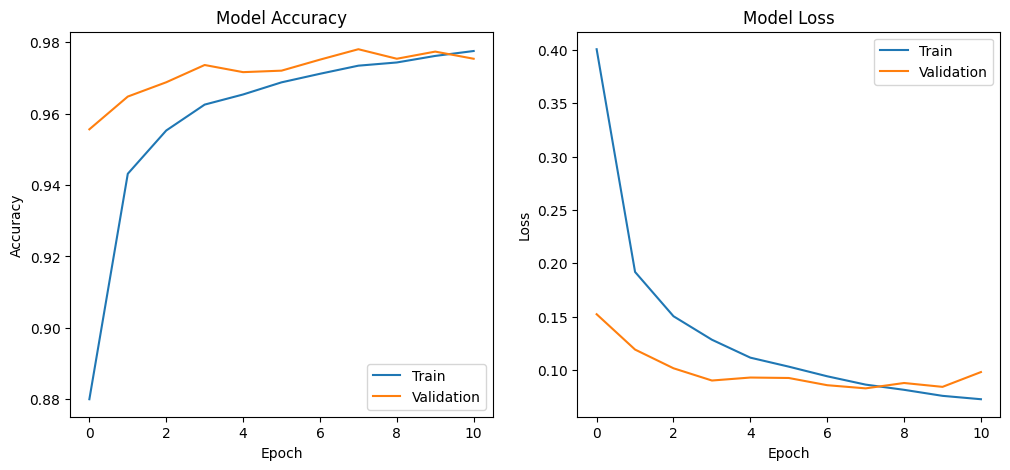

In [25]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()



## Predictions Visualization

313/313 [==============================] - 1s 2ms/step


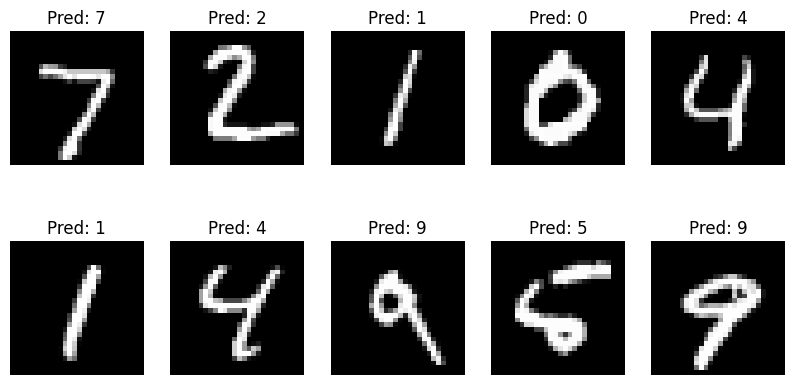

In [26]:
predictions = model.predict(X_test)

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}")
    plt.axis('off')

plt.show()

# Comparison of the different parameter tuning of the MLP

In [27]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam, SGD


### MODEL FUNCTION

In [28]:

def create_model(layers, activation, optimizer, use_dropout=False):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))

    for neurons in layers:
        model.add(Dense(neurons, activation=activation))
        if use_dropout:
            model.add(Dropout(0.3))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



### EXPERIMENT SETUP

In [29]:
experiments = [
    {"name": "Baseline", "layers": [128,64], "activation": "relu", "optimizer": Adam(), "dropout": False},
    {"name": "Deep Network", "layers": [256,128,64], "activation": "relu", "optimizer": Adam(), "dropout": False},
    {"name": "Tanh Activation", "layers": [128,64], "activation": "tanh", "optimizer": Adam(), "dropout": False},
    {"name": "SGD Optimizer", "layers": [128,64], "activation": "relu", "optimizer": SGD(), "dropout": False},
    {"name": "With Dropout", "layers": [128,64], "activation": "relu", "optimizer": Adam(), "dropout": True}
]


### TRAINING LOOP


Running Baseline...


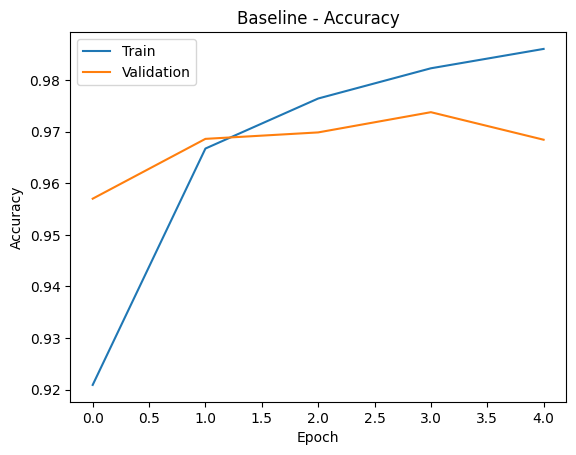

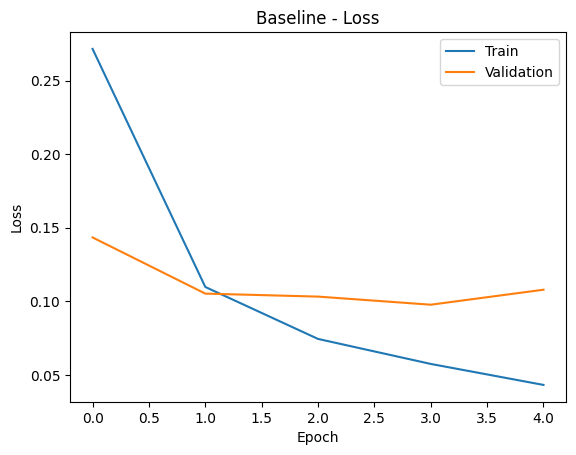

313/313 [==============================] - 0s 682us/step


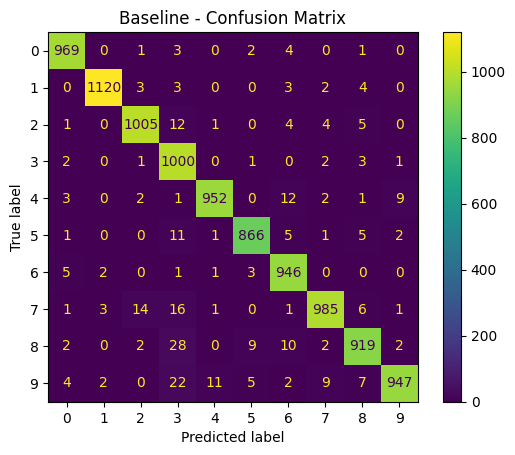

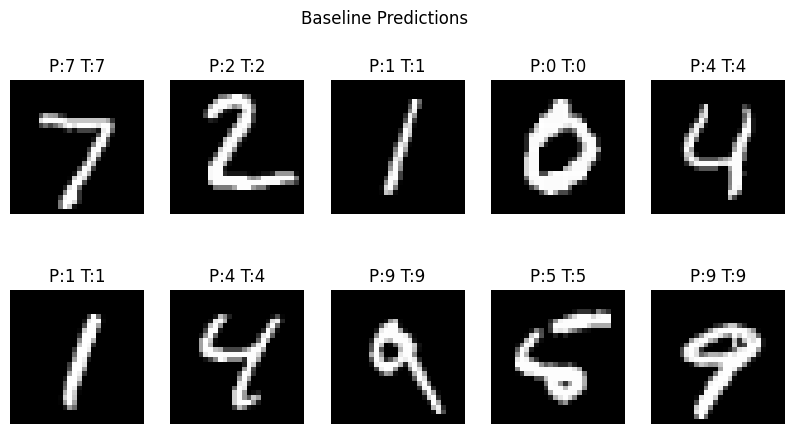


Running Deep Network...


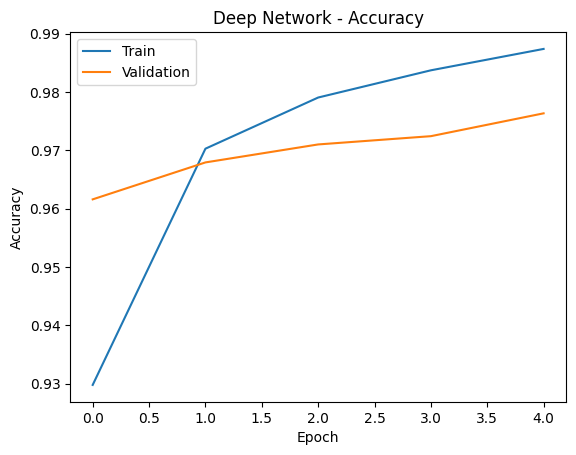

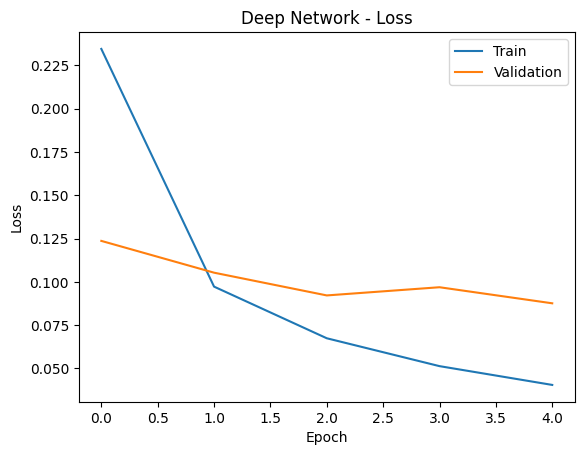

313/313 [==============================] - 0s 914us/step


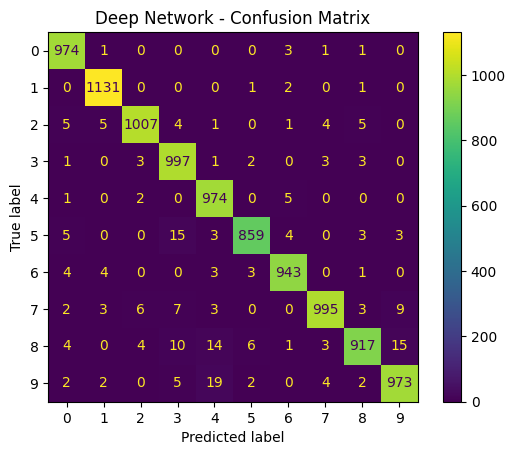

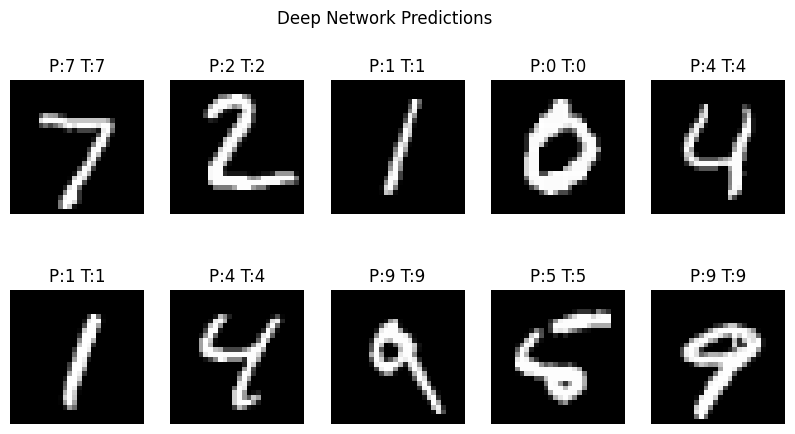


Running Tanh Activation...


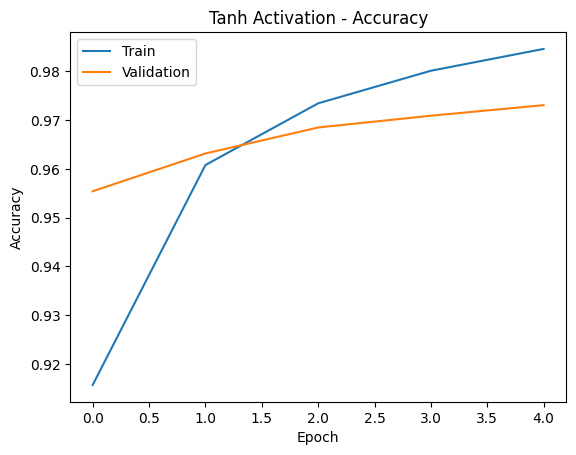

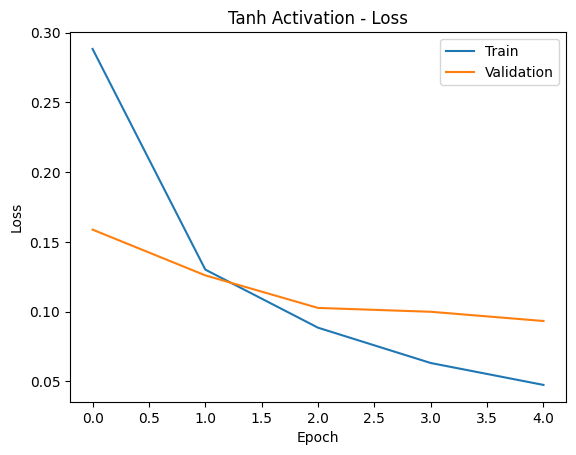

313/313 [==============================] - 0s 764us/step


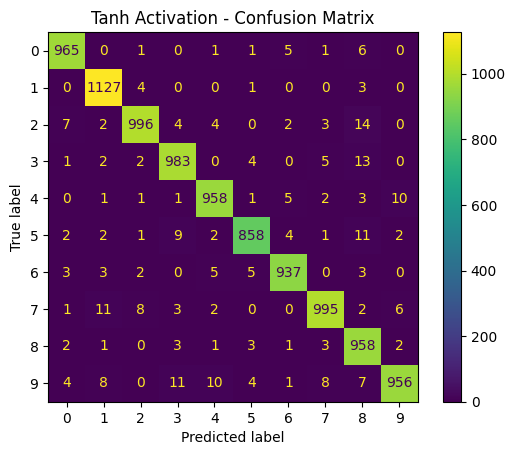

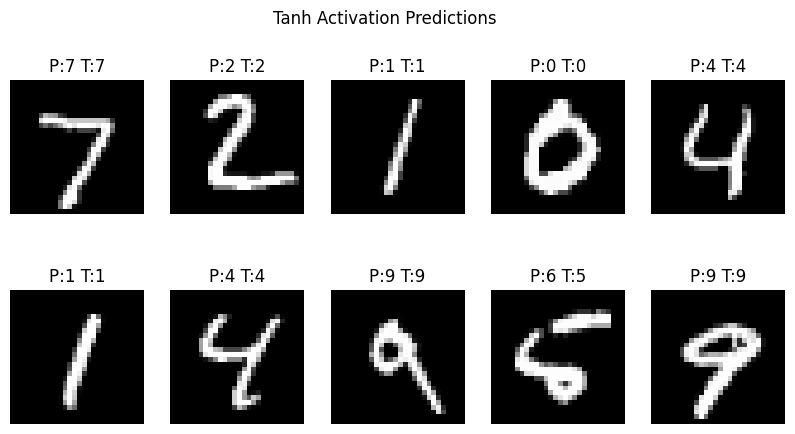


Running SGD Optimizer...


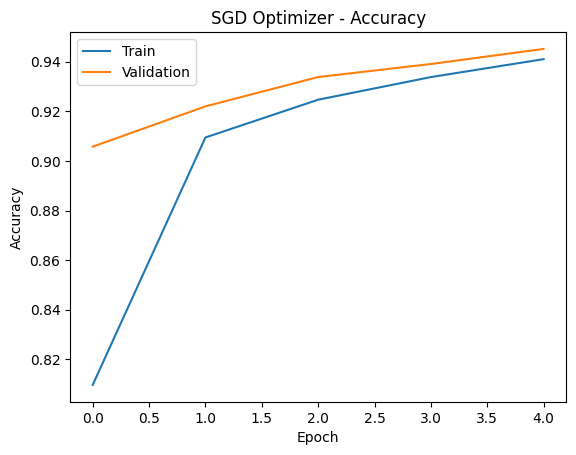

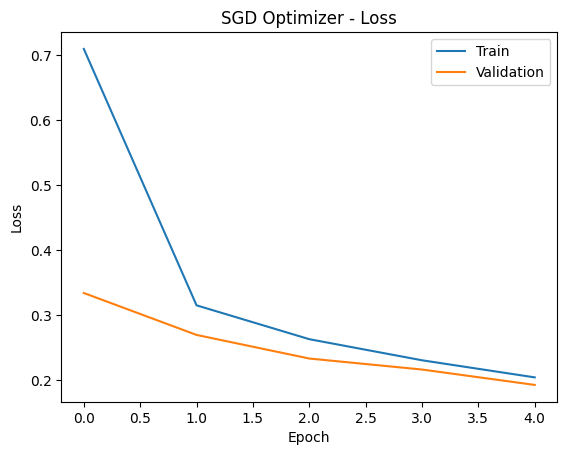

313/313 [==============================] - 0s 853us/step


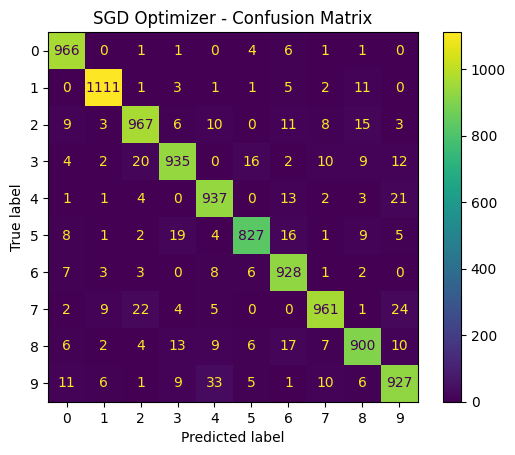

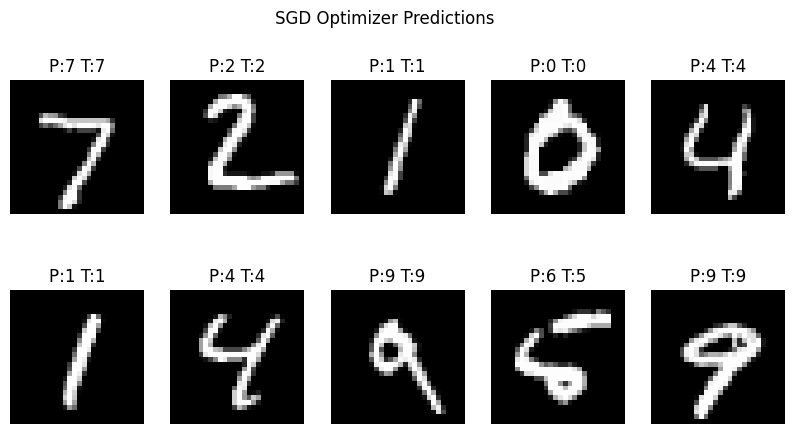


Running With Dropout...


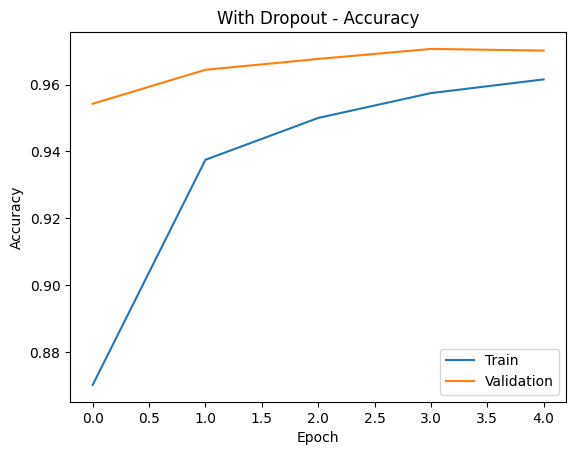

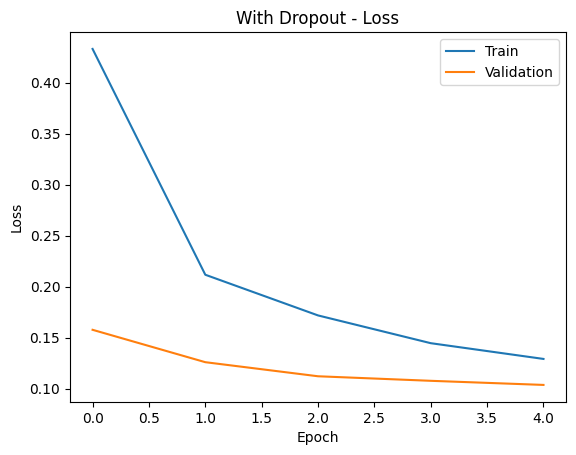

313/313 [==============================] - 0s 756us/step


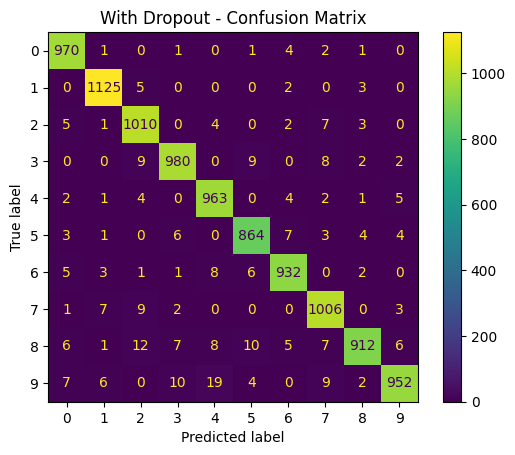

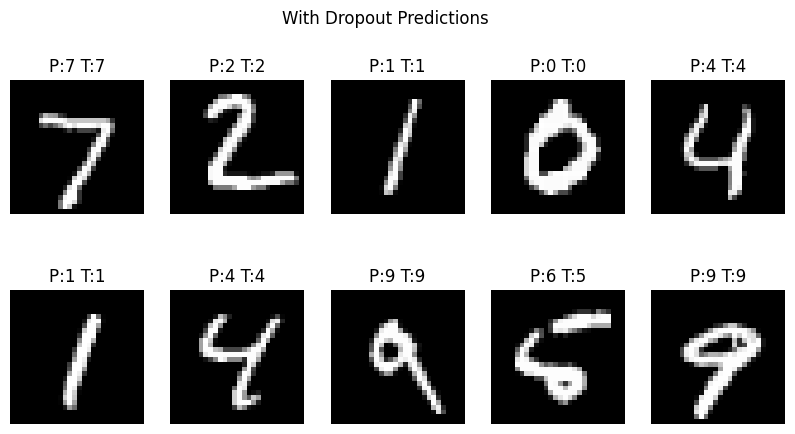

In [30]:
results = []

for exp in experiments:
    print(f"\nRunning {exp['name']}...")

    model = create_model(
        exp["layers"],
        exp["activation"],
        exp["optimizer"],
        exp["dropout"]
    )

    # -----> Training time
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    end_time = time.time()
    training_time = end_time - start_time

    # -----> Evaluation
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # -----> Save results
    results.append({
        "Experiment": exp["name"],
        "Accuracy": test_acc,
        "Training Time (sec)": training_time
    })

    # ----->PLOT TRAINING CURVES
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f"{exp['name']} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f"{exp['name']} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

    # ----->CONFUSION MATRIX
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{exp['name']} - Confusion Matrix")
    plt.show()

    # ----->PREDICTIONS VISUALIZATION
    plt.figure(figsize=(10,5))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(X_test[i], cmap='gray')
        plt.title(f"P:{y_pred_classes[i]} T:{y_true[i]}")
        plt.axis('off')

    plt.suptitle(f"{exp['name']} Predictions")
    plt.show()



Final Comparison:

        Experiment  Accuracy  Training Time (sec)
0         Baseline    0.9709             9.130908
1     Deep Network    0.9770            12.341773
2  Tanh Activation    0.9733             9.622998
3    SGD Optimizer    0.9459             9.461268
4     With Dropout    0.9714            10.336359


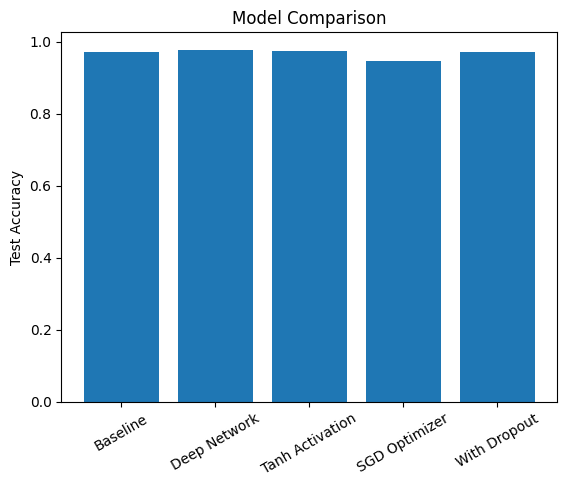

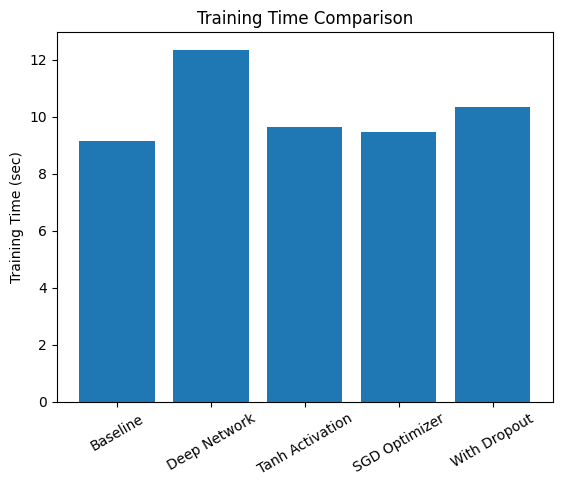

In [31]:
# -----> FINAL COMPARISON TABLE
df = pd.DataFrame(results)
print("\nFinal Comparison:\n")
print(df)

# ----->BAR PLOT (MODEL COMPARISON)
plt.figure()
plt.bar(df["Experiment"], df["Accuracy"])
plt.xticks(rotation=30)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.show()

plt.figure()
plt.bar(df["Experiment"], df["Training Time (sec)"])
plt.xticks(rotation=30)
plt.ylabel("Training Time (sec)")
plt.title("Training Time Comparison")
plt.show()